# Linear Regression from Scratch - Implementation with NumPy

## 1. Problem Setup

We consider a supervised learning problem with:

* A dataset of **$n$ samples**
* Each sample has **$d$ features**

We define:

* $X \in \mathbb{R}^{n \times d}$ → Feature matrix
* $y \in \mathbb{R}^{n}$ → Target vector
* $w \in \mathbb{R}^{d}$ → Weight vector
* $b \in \mathbb{R}$ → Bias term

### 1.1. Hypothesis (Model)

The linear regression model assumes a linear relationship between input features and the target:

$$
\hat{y} = Xw + b
$$

For a single sample $x^{(i)}$:

$$
\hat{y}^{(i)} = x^{(i)} \cdot w + b
$$

where:

* $\hat{y}$ is the predicted value
* $w$ contains the learned coefficients
* $b$ is the intercept

### 1.2. Loss Function (Mean Squared Error)

To measure the model's performance, we use the **Mean Squared Error (MSE)**:

$$
J(w, b) = \frac{1}{n} \sum_{i=1}^{n} \left(y^{(i)} - \hat{y}^{(i)}\right)^2
$$

In matrix form:

$$
J(w, b) = \frac{1}{n} | y - (Xw + b) |^2
$$

The goal is to find $w$ and $b$ that minimize this loss.

### 1.3. Gradients

To minimize the loss, we compute the gradients with respect to $w$ and $b$.

Gradient with respect to $w$:

$$
\nabla_w J = \frac{2}{n} X^T (Xw + b - y)
$$

Gradient with respect to $b$:

$$
\nabla_b J = \frac{2}{n} \sum_{i=1}^{n} (Xw + b - y)
$$

### 1.4. Gradient Descent Update Rule

We update the parameters iteratively using gradient descent:

$$
w := w - \alpha \nabla_w J
$$

$$
b := b - \alpha \nabla_b J
$$

where:

* $\alpha$ is the learning rate
* The process is repeated for a fixed number of iterations or until convergence

### 1.5. Objective

The objective of this notebook is to:

* Implement linear regression **from scratch**
* Use only NumPy for numerical computation
* Understand each mathematical step behind the algorithm
* Avoid using high-level libraries such as `scikit-learn`

## 3. Code testing with synthetic dataset

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from linear_regression import LinearRegression # script in the linear_regression.py file
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
# Set random seed for reproductibility
np.random.seed(42)

# Example : Generate a synthetic dataset
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [12]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

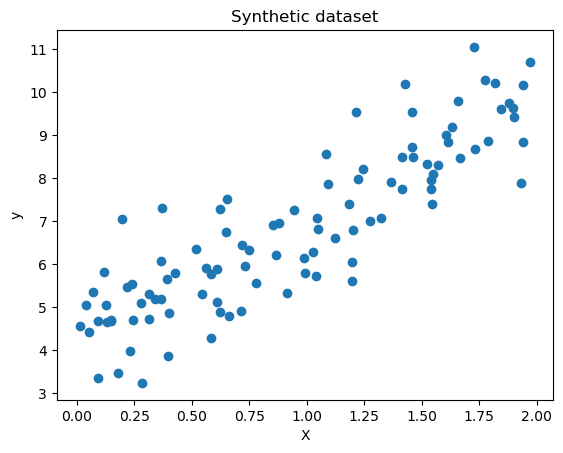

In [13]:
# Visualize dataset
plt.scatter(X, y)
plt.title("Synthetic dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
# Create and train model
model = LinearRegression(learning_rate=0.1, n_iters=1000)
model.fit(X, y)

Learned weight: [2.77011339]
Learned bias: 4.215096157546739


In [15]:
# Predictions
y_pred = model.predict(X_test)

In [18]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Learned bias:", model.b)
print("Learned weight:", model.w)
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

Learned bias: 4.215096157546739
Learned weight: [2.77011339]
MSE: 0.63
RMSE: 0.80
R²: 0.81


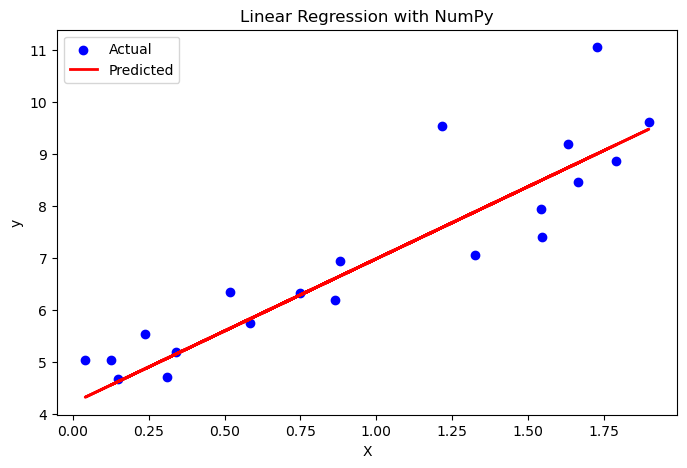

In [19]:
# Plot results
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with NumPy')
plt.legend()
plt.show()

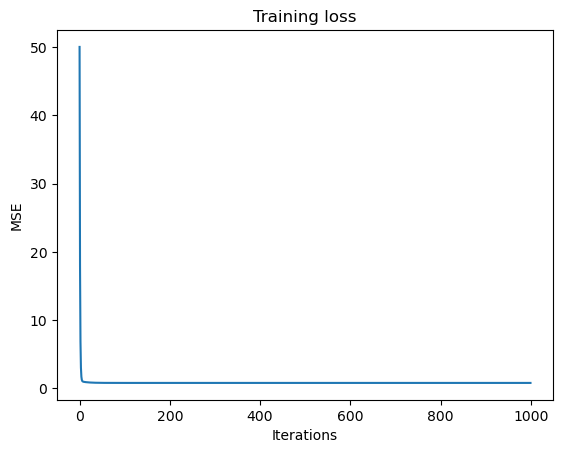

In [21]:
# Plot training loss
plt.plot(model.losses)
plt.title("Training loss")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()